In [65]:
import warnings
warnings.filterwarnings("ignore")

# 🌍 Obiettivo
L'obiettivo di questa parte del notebook è creare un modello di regressione che permetta di stimare la quantità di emissioni (ad esempio di CO, NOx, ecc.) sulla base delle caratteristiche della zona. Queste stime servono per evidenziare le aree con livelli critici di inquinamento.
Predire in modo accurato:
- Le **emissioni totali di CO₂** (in grammi)
- Il **consumo energetico totale** (in megajoule)

utilizzando dati sul traffico, informazioni spaziali e temporali, e indicatori di consumo/emissioni. Così da individuare le zone critiche in modo da poter intervenire.

## Caricamento datset

In [66]:
#Importiamo le librerie 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler

#Leggiamo il dataset
dataset = pd.read_csv('smart_mobility_dataset.csv')
dataset2= pd.read_csv('dataset_traffic_accident_prediction1.csv', sep=';')
dataset3= pd.read_csv('TrafficTwoMonth.csv')

dataset.head()


,Timestamp,Latitude,Longitude,Vehicle_Count,Traffic_Speed_kmh,Road_Occupancy_%,Traffic_Light_State,Weather_Condition,Accident_Report,Sentiment_Score,Ride_Sharing_Demand,Parking_Availability,Emission_Levels_g_km,Energy_Consumption_L_h,Traffic_Condition
0,2024-03-01 00:00:00,40.842275,-73.703149,205,49.893435,82.652780,Yellow,Clear,0,-0.609199,2,45,450.760055,19.574337,High
1,2024-03-01 00:05:00,40.831119,-73.987354,202,22.383965,45.829298,Green,Clear,0,0.965442,16,1,321.800341,5.385554,High
2,2024-03-01 00:10:00,40.819549,-73.732462,252,46.889699,82.772465,Green,Rain,0,0.289660,16,49,231.152655,10.277477,High
3,2024-03-01 00:15:00,40.725849,-73.980134,37,5.730536,37.695567,Red,Fog,0,-0.271965,66,10,410.384292,29.243279,High
4,2024-03-01 00:20:00,40.813265,-73.961631,64,61.348034,22.313358,Red,Snow,0,-0.797606,3,5,364.466342,16.801459,Low


In [67]:
dataset['Road_Condition']=dataset2['Road_Condition']
dataset.head()

,Timestamp,Latitude,Longitude,Vehicle_Count,Traffic_Speed_kmh,Road_Occupancy_%,Traffic_Light_State,Weather_Condition,Accident_Report,Sentiment_Score,Ride_Sharing_Demand,Parking_Availability,Emission_Levels_g_km,Energy_Consumption_L_h,Traffic_Condition,Road_Condition
0,2024-03-01 00:00:00,40.842275,-73.703149,205,49.893435,82.652780,Yellow,Clear,0,-0.609199,2,45,450.760055,19.574337,High,Wet
1,2024-03-01 00:05:00,40.831119,-73.987354,202,22.383965,45.829298,Green,Clear,0,0.965442,16,1,321.800341,5.385554,High,Wet
2,2024-03-01 00:10:00,40.819549,-73.732462,252,46.889699,82.772465,Green,Rain,0,0.289660,16,49,231.152655,10.277477,High,Icy
3,2024-03-01 00:15:00,40.725849,-73.980134,37,5.730536,37.695567,Red,Fog,0,-0.271965,66,10,410.384292,29.243279,High,Under Construction
4,2024-03-01 00:20:00,40.813265,-73.961631,64,61.348034,22.313358,Red,Snow,0,-0.797606,3,5,364.466342,16.801459,Low,Dry


In [68]:
dataset=dataset.drop(columns=['Traffic_Condition', 'Vehicle_Count'], axis=1)

cols_to_add = ['CarCount', 'BikeCount', 'BusCount', 'TruckCount', 'Total', 'Traffic Situation']
for col in cols_to_add:
    dataset[col] = dataset3[col].values[:5000]

dataset.head()

,Timestamp,Latitude,Longitude,Traffic_Speed_kmh,Road_Occupancy_%,Traffic_Light_State,Weather_Condition,Accident_Report,Sentiment_Score,Ride_Sharing_Demand,Parking_Availability,Emission_Levels_g_km,Energy_Consumption_L_h,Road_Condition,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation
0,2024-03-01 00:00:00,40.842275,-73.703149,49.893435,82.652780,Yellow,Clear,0,-0.609199,2,45,450.760055,19.574337,Wet,13,2,2,24,41,normal
1,2024-03-01 00:05:00,40.831119,-73.987354,22.383965,45.829298,Green,Clear,0,0.965442,16,1,321.800341,5.385554,Wet,14,1,1,36,52,normal
2,2024-03-01 00:10:00,40.819549,-73.732462,46.889699,82.772465,Green,Rain,0,0.289660,16,49,231.152655,10.277477,Icy,10,2,2,32,46,normal
3,2024-03-01 00:15:00,40.725849,-73.980134,5.730536,37.695567,Red,Fog,0,-0.271965,66,10,410.384292,29.243279,Under Construction,10,2,2,36,50,normal
4,2024-03-01 00:20:00,40.813265,-73.961631,61.348034,22.313358,Red,Snow,0,-0.797606,3,5,364.466342,16.801459,Dry,11,2,1,34,48,normal


## 1 - Analisi Preliminare

In [69]:
#Visualizziamo i tipi delle colonne
print(f"{dataset.dtypes}\n")

print("Number of rows: ", dataset.shape[0])
print("Number of columns: ", dataset.shape[1])

Timestamp                  object
Latitude                  float64
Longitude                 float64
Traffic_Speed_kmh         float64
Road_Occupancy_%          float64
Traffic_Light_State        object
Weather_Condition          object
Accident_Report             int64
Sentiment_Score           float64
Ride_Sharing_Demand         int64
Parking_Availability        int64
Emission_Levels_g_km      float64
Energy_Consumption_L_h    float64
Road_Condition             object
CarCount                    int64
BikeCount                   int64
BusCount                    int64
TruckCount                  int64
Total                       int64
Traffic Situation          object
dtype: object

Number of rows:  5000
Number of columns:  20


In [70]:
# calcolo statistiche descrittive
dataset.describe()

,Latitude,Longitude,Traffic_Speed_kmh,Road_Occupancy_%,Accident_Report,Sentiment_Score,Ride_Sharing_Demand,Parking_Availability,Emission_Levels_g_km,Energy_Consumption_L_h,CarCount,BikeCount,BusCount,TruckCount,Total
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000
mean,40.749645,-73.847433,42.111096,54.748397,0.096000,-0.005652,50.487800,24.613000,272.174927,17.343243,64.57580,11.661800,12.371200,19.267200,107.876000
std,0.086123,0.086204,21.707720,26.145238,0.294621,0.583790,28.484426,14.532511,130.086372,7.208277,44.45762,11.329832,11.973708,10.976425,55.054326
min,40.600016,-73.999987,5.002789,10.005031,0.000000,-0.999819,1.000000,0.000000,50.136855,5.003787,5.00000,0.000000,0.000000,0.000000,21.000000
25%,40.675403,-73.920281,23.195752,32.089653,0.000000,-0.500154,26.000000,12.000000,160.564433,11.098761,18.00000,2.000000,2.000000,10.000000,54.000000
50%,40.748875,-73.846058,42.191599,54.657297,0.000000,-0.010564,50.000000,24.000000,272.045513,17.153791,62.00000,9.000000,10.000000,18.000000,103.000000
75%,40.824735,-73.771685,60.751760,77.581720,0.000000,0.500518,75.000000,37.000000,382.242055,23.516595,102.00000,18.000000,20.000000,28.000000,150.000000
max,40.899972,-73.700159,79.997556,99.999729,1.000000,0.999354,99.000000,49.000000,499.922663,29.995416,180.00000,70.000000,50.000000,60.000000,279.000000


In [71]:
#Verifica dati mancanti 
missing_values = dataset.isnull().sum()
print(missing_values)

Timestamp                  0
Latitude                   0
Longitude                  0
Traffic_Speed_kmh          0
Road_Occupancy_%           0
Traffic_Light_State        0
Weather_Condition          0
Accident_Report            0
Sentiment_Score            0
Ride_Sharing_Demand        0
Parking_Availability       0
Emission_Levels_g_km       0
Energy_Consumption_L_h     0
Road_Condition            42
CarCount                   0
BikeCount                  0
BusCount                   0
TruckCount                 0
Total                      0
Traffic Situation          0
dtype: int64


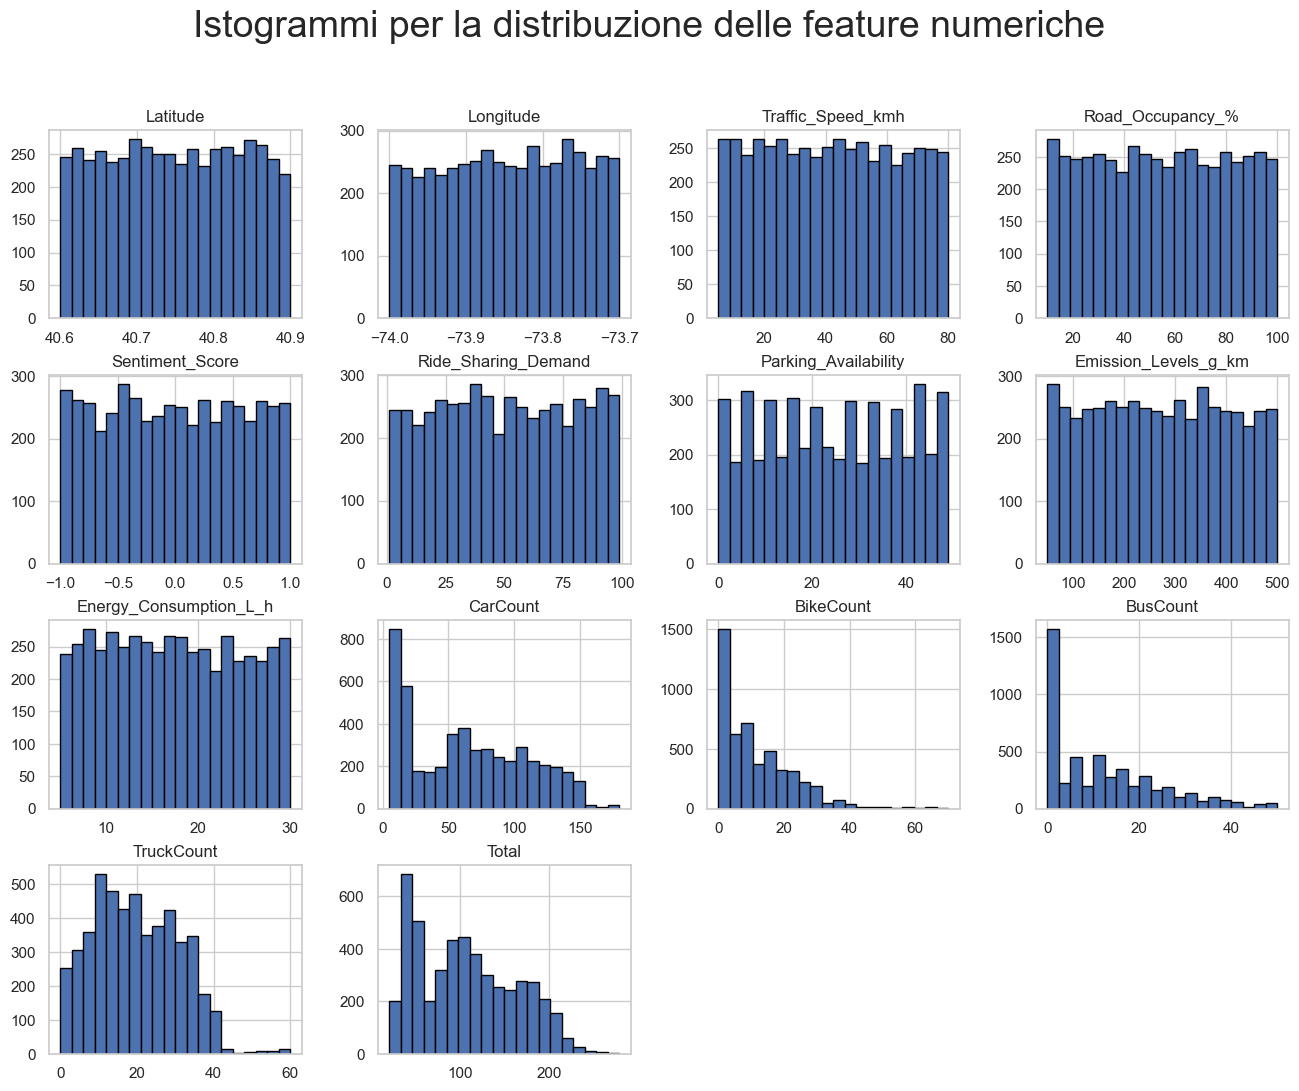

In [72]:
# Istogrammi per la distribuzione delle feature numeriche

# Elenco delle colonne da escludere
columns_to_exclude = ['Traffic_Light_State', 'Weather_Condition', 'Accident_Report', 'Traffic Situation']

# Creiamo il subset dei dati senza le feature da escludere
data_subset = dataset.drop(columns=columns_to_exclude)
data_subset.hist(bins=20, figsize=(16, 12), edgecolor='black')
plt.suptitle("Istogrammi per la distribuzione delle feature numeriche", fontsize=27)
plt.show()

latitudine e logitudine sono pressochè costanti, possiamo eliminarle

In [73]:
#dataset=dataset.drop(columns=['Latitude', 'Longitude'], axis=1)
dataset.head()

,Timestamp,Latitude,Longitude,Traffic_Speed_kmh,Road_Occupancy_%,Traffic_Light_State,Weather_Condition,Accident_Report,Sentiment_Score,Ride_Sharing_Demand,Parking_Availability,Emission_Levels_g_km,Energy_Consumption_L_h,Road_Condition,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation
0,2024-03-01 00:00:00,40.842275,-73.703149,49.893435,82.652780,Yellow,Clear,0,-0.609199,2,45,450.760055,19.574337,Wet,13,2,2,24,41,normal
1,2024-03-01 00:05:00,40.831119,-73.987354,22.383965,45.829298,Green,Clear,0,0.965442,16,1,321.800341,5.385554,Wet,14,1,1,36,52,normal
2,2024-03-01 00:10:00,40.819549,-73.732462,46.889699,82.772465,Green,Rain,0,0.289660,16,49,231.152655,10.277477,Icy,10,2,2,32,46,normal
3,2024-03-01 00:15:00,40.725849,-73.980134,5.730536,37.695567,Red,Fog,0,-0.271965,66,10,410.384292,29.243279,Under Construction,10,2,2,36,50,normal
4,2024-03-01 00:20:00,40.813265,-73.961631,61.348034,22.313358,Red,Snow,0,-0.797606,3,5,364.466342,16.801459,Dry,11,2,1,34,48,normal


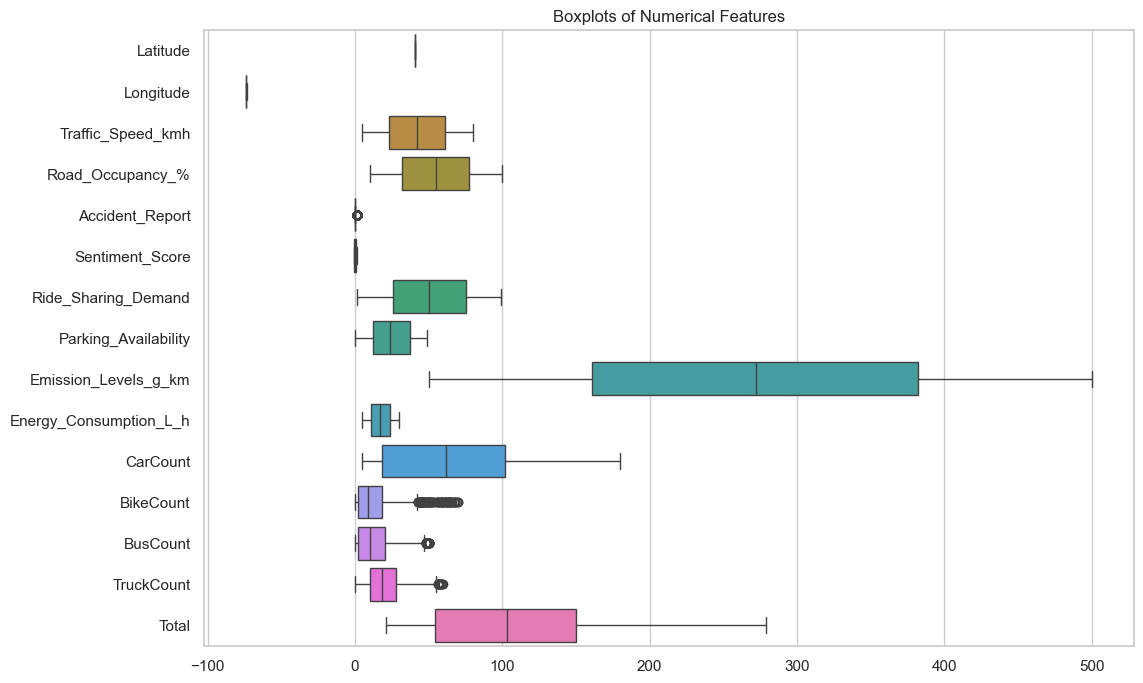

In [74]:
# Boxplot per le feature numeriche
plt.figure(figsize=(12, 8))
sns.boxplot(data=dataset, orient="h") #boxplot serve per vedere eventuali outliers
plt.title("Boxplots of Numerical Features")
plt.show()

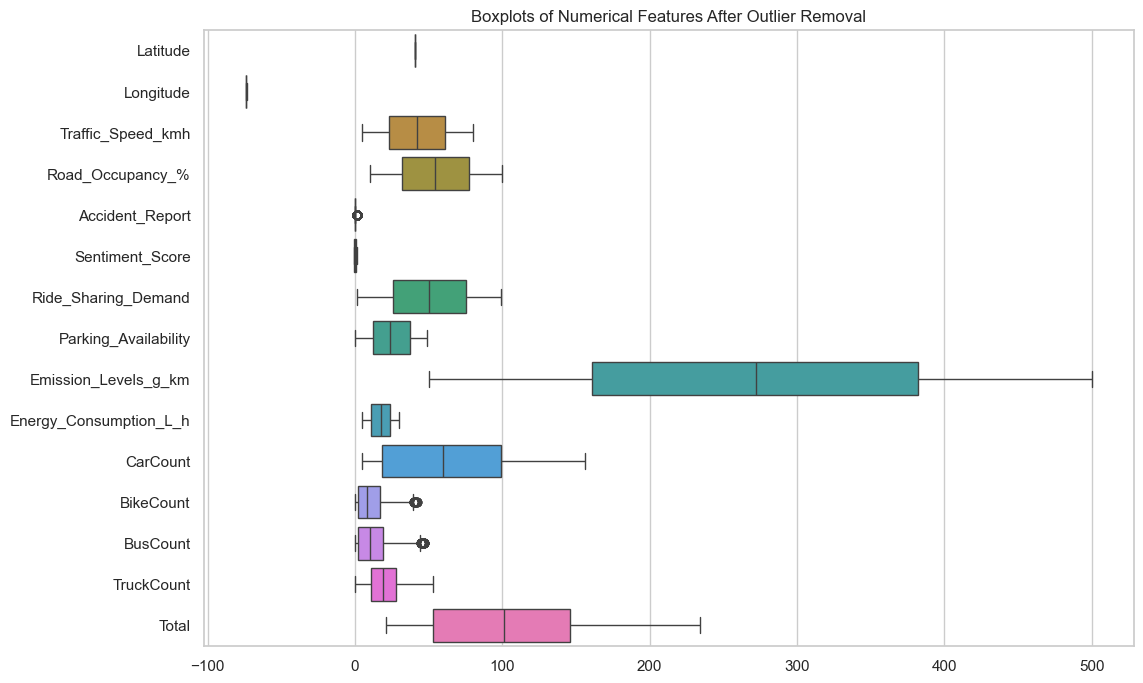

In [75]:
# Rimozione outlier per CarCount, BikeCount, TruckCount usando l'IQR
def remove_outliers_iqr(df, columns):
    df_clean = df.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
    return df_clean


dataset = remove_outliers_iqr(dataset, ['CarCount', 'BikeCount', 'TruckCount', 'BusCount'])
dataset.head()
# Verifica della presenza di outlier dopo la rimozione
plt.figure(figsize=(12, 8))
sns.boxplot(data=dataset, orient="h")
plt.title("Boxplots of Numerical Features After Outlier Removal")
plt.show()


In [76]:
# Assicuro che 'Timestamp' sia in formato datetime
dataset['Timestamp'] = pd.to_datetime(dataset['Timestamp'])

# Giorno della settimana (0=Lunedì, 6=Domenica)
dataset['DayOfWeek'] = dataset['Timestamp'].dt.dayofweek

# Week-end (1 se sabato o domenica, 0 altrimenti)
dataset['Is_Weekend'] = dataset['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

# Giorno del mese
dataset['Day'] = dataset['Timestamp'].dt.day

# Mese
dataset['Month'] = dataset['Timestamp'].dt.month

# Ora del giorno
dataset['Hour'] = dataset['Timestamp'].dt.hour

dataset.head()

,Timestamp,Latitude,Longitude,Traffic_Speed_kmh,Road_Occupancy_%,Traffic_Light_State,Weather_Condition,Accident_Report,Sentiment_Score,Ride_Sharing_Demand,...,BikeCount,BusCount,TruckCount,Total,Traffic Situation,DayOfWeek,Is_Weekend,Day,Month,Hour
0,2024-03-01 00:00:00,40.842275,-73.703149,49.893435,82.652780,Yellow,Clear,0,-0.609199,2,...,2,2,24,41,normal,4,0,1,3,0
1,2024-03-01 00:05:00,40.831119,-73.987354,22.383965,45.829298,Green,Clear,0,0.965442,16,...,1,1,36,52,normal,4,0,1,3,0
2,2024-03-01 00:10:00,40.819549,-73.732462,46.889699,82.772465,Green,Rain,0,0.289660,16,...,2,2,32,46,normal,4,0,1,3,0
3,2024-03-01 00:15:00,40.725849,-73.980134,5.730536,37.695567,Red,Fog,0,-0.271965,66,...,2,2,36,50,normal,4,0,1,3,0
4,2024-03-01 00:20:00,40.813265,-73.961631,61.348034,22.313358,Red,Snow,0,-0.797606,3,...,2,1,34,48,normal,4,0,1,3,0


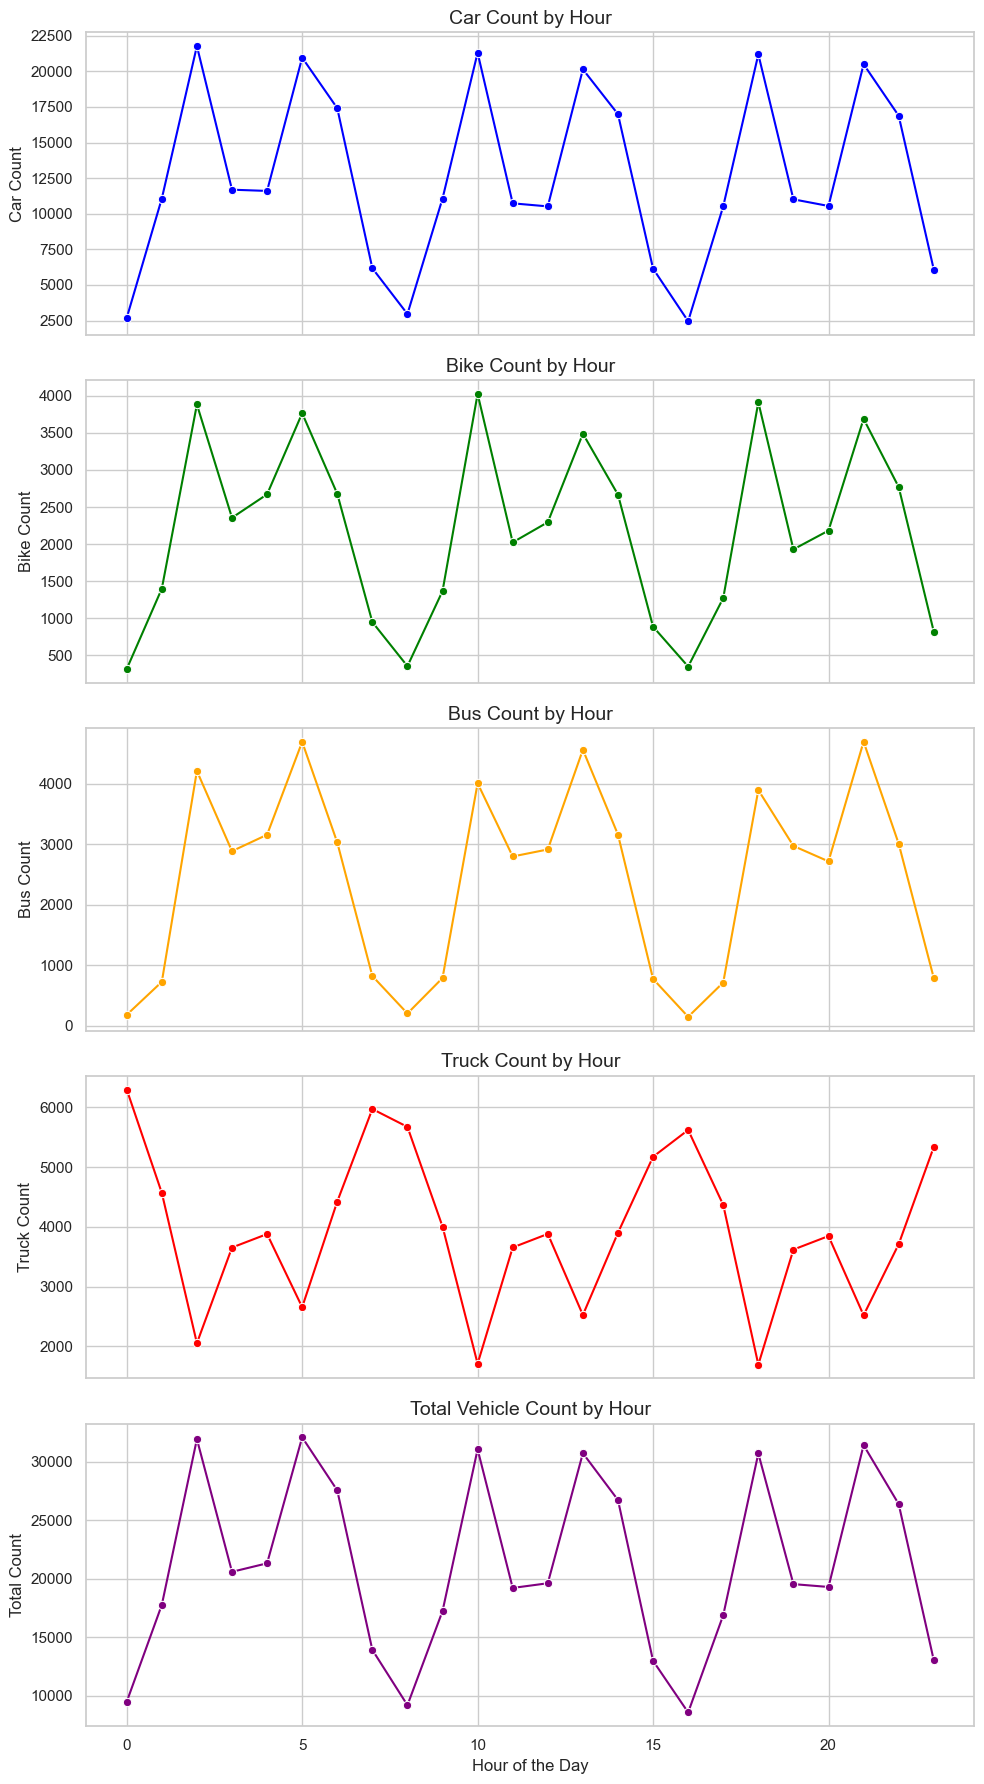

In [77]:
# Select only numeric columns for summation
numeric_columns = ['CarCount', 'BikeCount', 'BusCount', 'TruckCount', 'Total']
# Group by hour and sum the vehicle counts
hourly_data = dataset.groupby('Hour')[numeric_columns].sum()

# Set the figure size and layout for separate plots
fig, axes = plt.subplots(5, 1, figsize=(10, 18), sharex=True)

# Plot for CarCount
sns.lineplot(x=hourly_data.index, y=hourly_data['CarCount'], ax=axes[0], color='blue', marker='o')
axes[0].set_title('Car Count by Hour', fontsize=14)
axes[0].set_ylabel('Car Count')

# Plot for BikeCount
sns.lineplot(x=hourly_data.index, y=hourly_data['BikeCount'], ax=axes[1], color='green', marker='o')
axes[1].set_title('Bike Count by Hour', fontsize=14)
axes[1].set_ylabel('Bike Count')

# Plot for BusCount
sns.lineplot(x=hourly_data.index, y=hourly_data['BusCount'], ax=axes[2], color='orange', marker='o')
axes[2].set_title('Bus Count by Hour', fontsize=14)
axes[2].set_ylabel('Bus Count')

# Plot for TruckCount
sns.lineplot(x=hourly_data.index, y=hourly_data['TruckCount'], ax=axes[3], color='red', marker='o')
axes[3].set_title('Truck Count by Hour', fontsize=14)
axes[3].set_ylabel('Truck Count')

# Plot for Total
sns.lineplot(x=hourly_data.index, y=hourly_data['Total'], ax=axes[4], color='purple', marker='o')
axes[4].set_title('Total Vehicle Count by Hour', fontsize=14)
axes[4].set_xlabel('Hour of the Day')
axes[4].set_ylabel('Total Count')

# Adjust the layout to prevent overlap
plt.tight_layout()
plt.show()

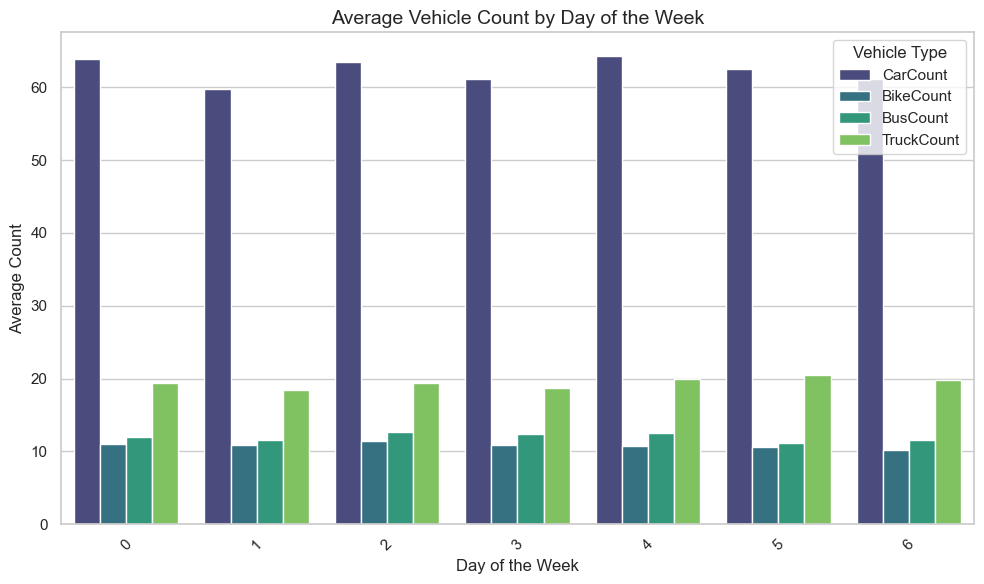

In [78]:
# Select only numeric columns, and then choose the specific columns you want
numeric_columns = ['CarCount', 'BikeCount', 'BusCount', 'TruckCount']

# Group by 'Day of the week' and calculate the mean for only the selected numeric columns
grouped_df = dataset.groupby('DayOfWeek')[numeric_columns].mean()

# Reset the index to make 'Day of the week' a column again
grouped_df = grouped_df.reset_index()

# Use the melt function to reshape the DataFrame for seaborn
grouped_df_melted = pd.melt(grouped_df, id_vars='DayOfWeek', var_name='Vehicle Type', value_name='Count')

# Set plot style and size
plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")

# Create the barplot
sns.barplot(x='DayOfWeek', y='Count', hue='Vehicle Type', data=grouped_df_melted, palette='viridis')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Add title and labels
plt.title('Average Vehicle Count by Day of the Week', fontsize=14)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Average Count', fontsize=12)

# Show the plot
plt.tight_layout()
plt.show()

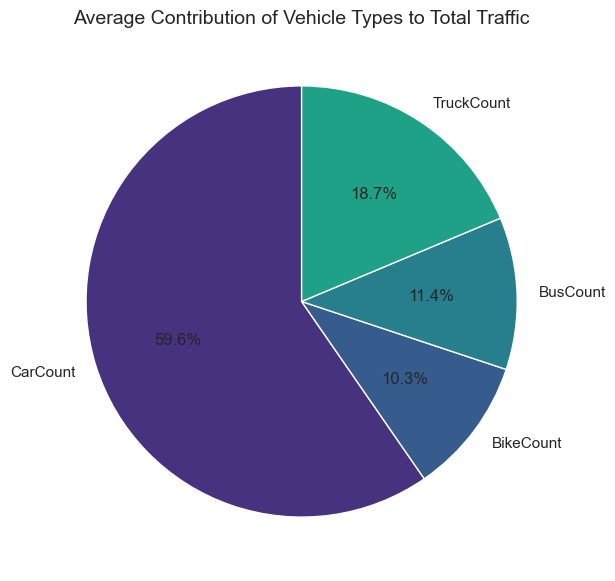

In [79]:
# Pie chart for average contribution of each vehicle type to total traffic
average_vehicle_counts = dataset[['CarCount', 'BikeCount', 'BusCount', 'TruckCount']].mean()

plt.figure(figsize=(7, 7))
plt.pie(average_vehicle_counts, labels=average_vehicle_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('viridis'))

plt.title('Average Contribution of Vehicle Types to Total Traffic', fontsize=14)
plt.show()

### Analisi dei Istogrammi delle Feature Categoriche


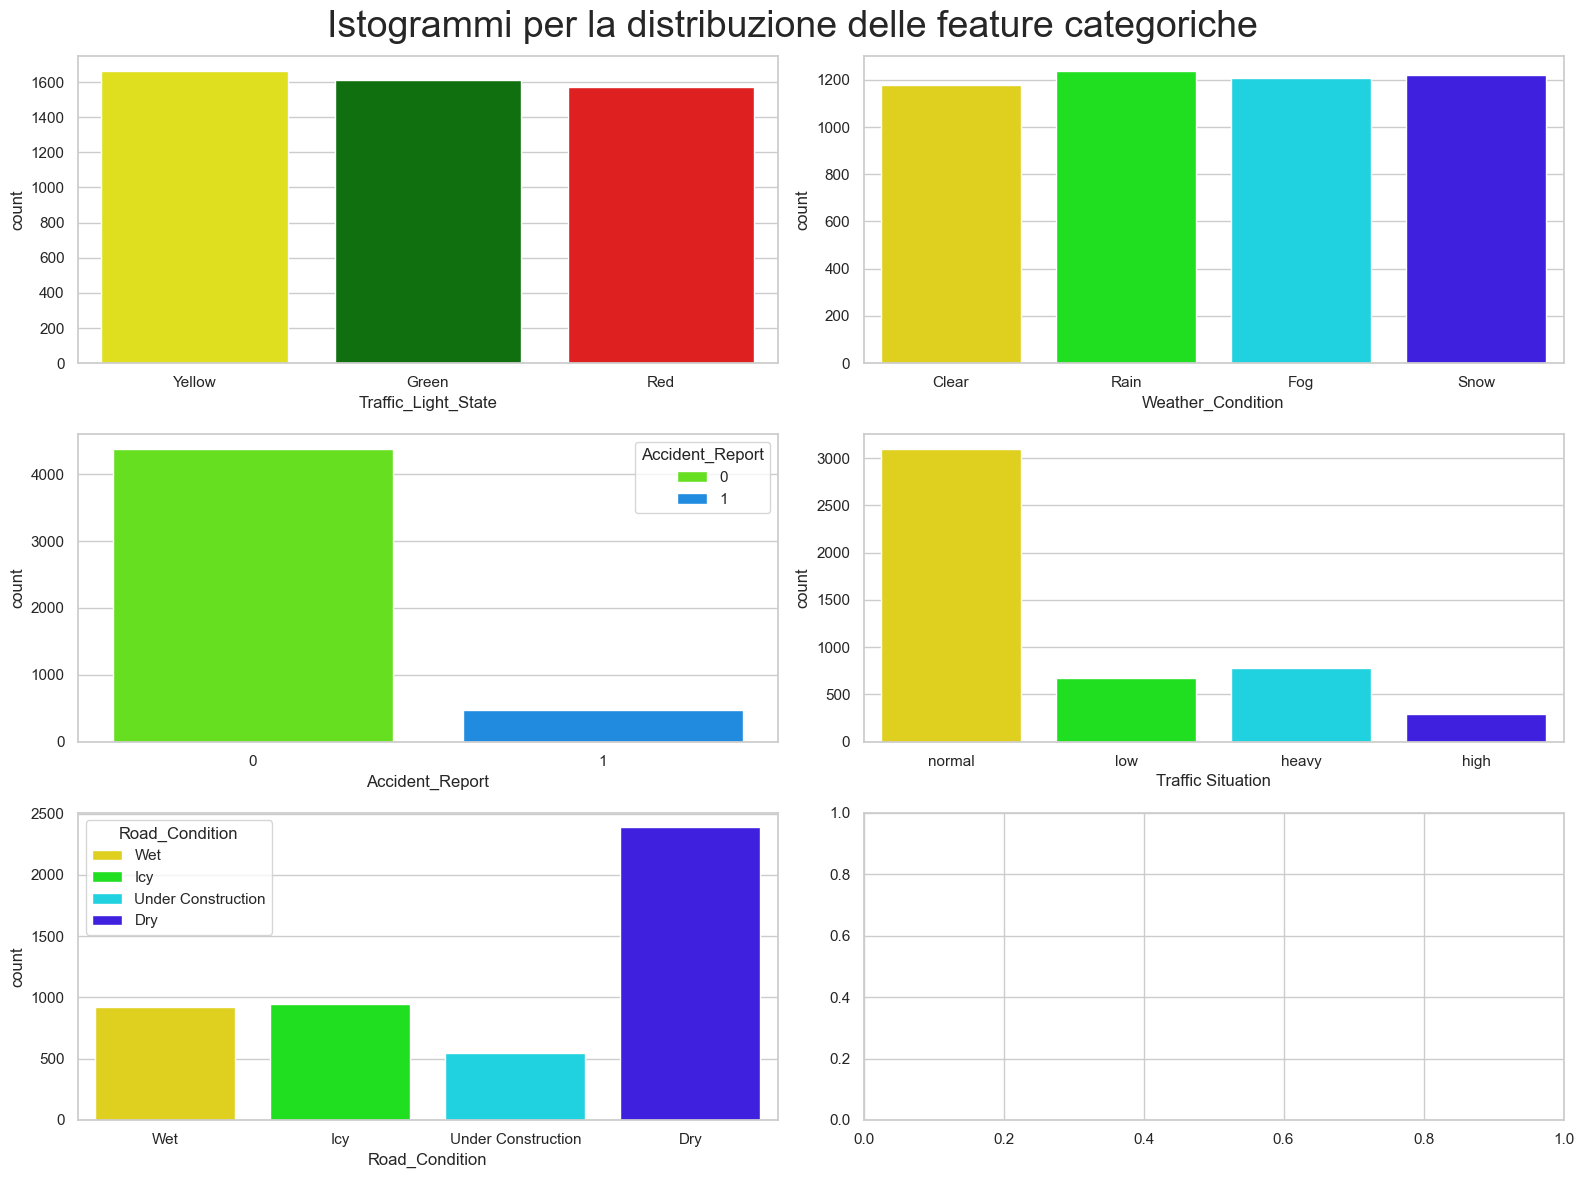

In [80]:
# Istogrammi per le features categoriche
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
sns.countplot(data=dataset, x='Traffic_Light_State', hue='Traffic_Light_State', ax=axes[0, 0], palette={'Red': 'red', 'Yellow': 'yellow', 'Green': 'green'})
sns.countplot(data=dataset, x='Weather_Condition', hue='Weather_Condition', ax=axes[0, 1], palette='gist_rainbow')
sns.countplot(data=dataset, x='Accident_Report', hue='Accident_Report', ax=axes[1, 0], palette='gist_rainbow')
sns.countplot(data=dataset, x='Traffic Situation', hue='Traffic Situation', ax=axes[1, 1], palette='gist_rainbow')
sns.countplot(data=dataset, x='Road_Condition', hue='Road_Condition', ax=axes[2, 0], palette='gist_rainbow')
plt.suptitle("Istogrammi per la distribuzione delle feature categoriche", fontsize=27)
plt.tight_layout()
plt.show()

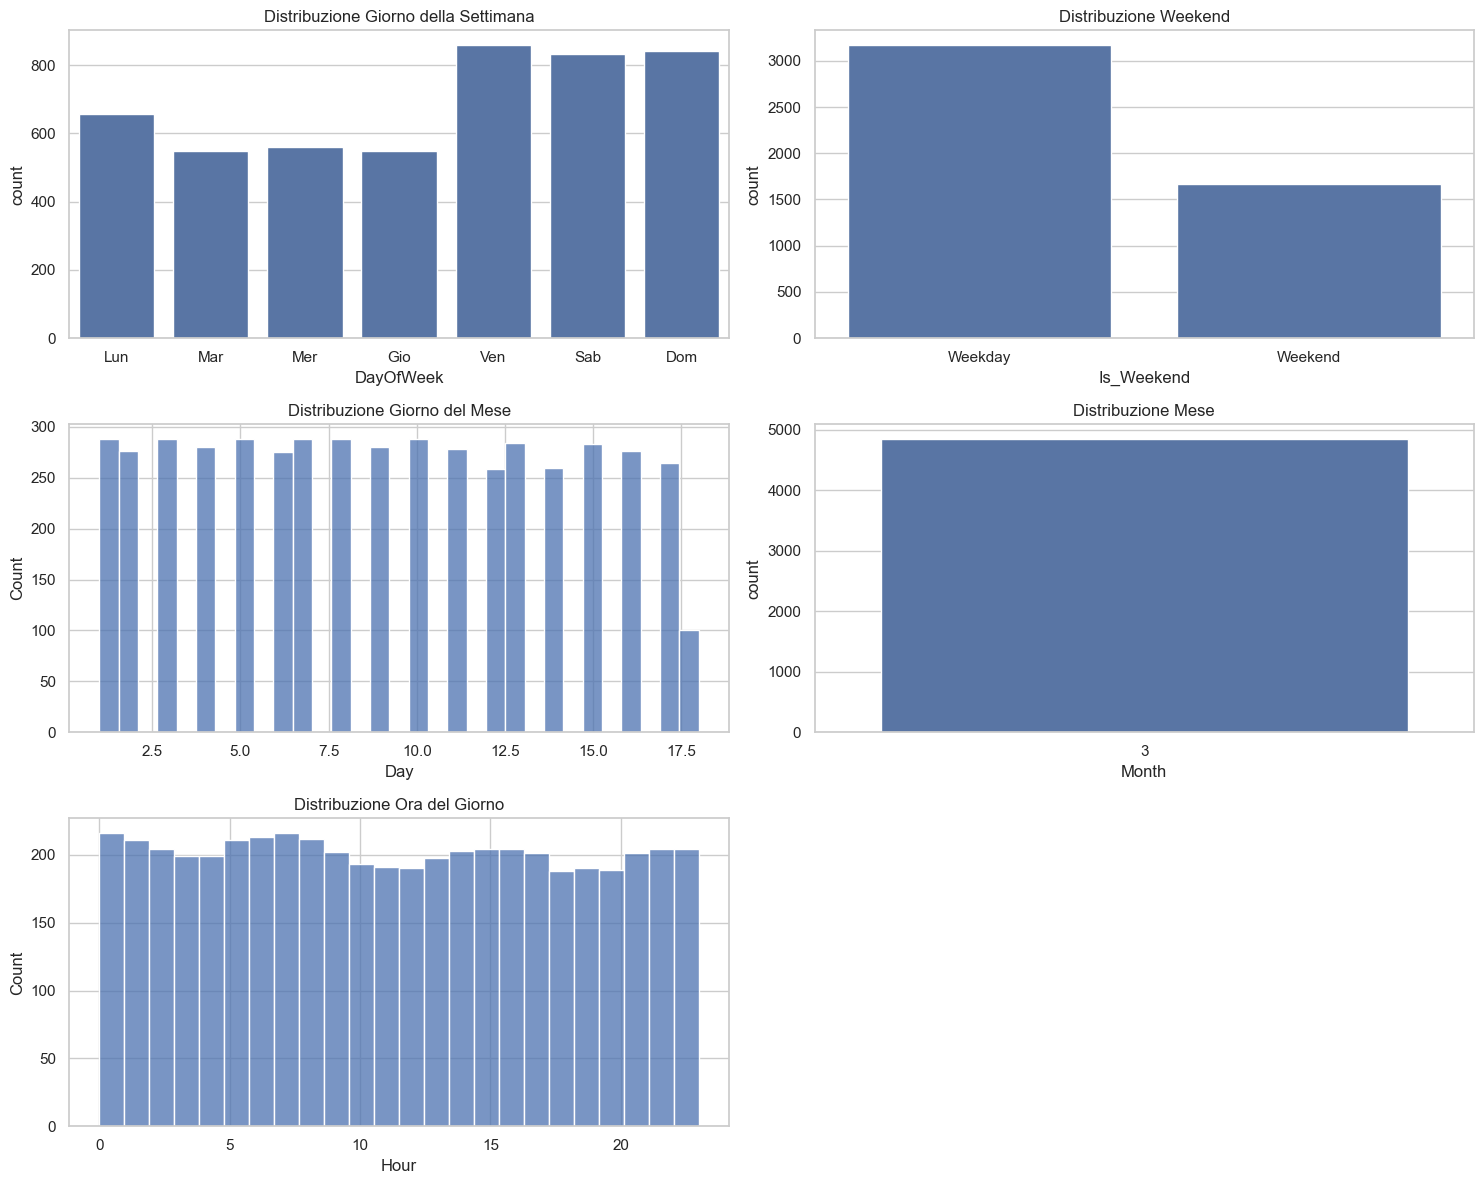

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

# Imposta lo stile di seaborn
sns.set(style="whitegrid")

# Crea una figura con sottotrame
fig, axes = plt.subplots(3, 2, figsize=(15, 12))

# Distribuzione del giorno della settimana
sns.countplot(x='DayOfWeek', data=dataset, ax=axes[0, 0])
axes[0, 0].set_title('Distribuzione Giorno della Settimana')
# Per asse con 7 giorni della settimana
axes[0, 0].set_xticks(range(7))  # Imposta i tick in 0-6
axes[0, 0].set_xticklabels(['Lun', 'Mar', 'Mer', 'Gio', 'Ven', 'Sab', 'Dom'])

# Distribuzione weekend
sns.countplot(x='Is_Weekend', data=dataset, ax=axes[0, 1])
axes[0, 1].set_title('Distribuzione Weekend')
# Per asse con 2 valori: Weekday vs Weekend
axes[0, 1].set_xticks([0, 1])  # Imposta 2 tick: posizione 0 e 1
axes[0, 1].set_xticklabels(['Weekday', 'Weekend'])


# Distribuzione giorno del mese
sns.histplot(dataset['Day'], bins=31, kde=False, ax=axes[1, 0])
axes[1, 0].set_title('Distribuzione Giorno del Mese')

# Distribuzione mese
sns.countplot(x='Month', data=dataset, ax=axes[1, 1])
axes[1, 1].set_title('Distribuzione Mese')

# Distribuzione ora del giorno
sns.histplot(dataset['Hour'], bins=24, kde=False, ax=axes[2, 0])
axes[2, 0].set_title('Distribuzione Ora del Giorno')

# Nascondi il subplot vuoto
axes[2, 1].axis('off')

# Mostra i grafici
plt.tight_layout()
plt.show()


## 2 - Preparazione dei dati

In [82]:
# cancellazione delle feature inutili per i nostri obiettivi e costanti
dataset=dataset.drop(columns=['Month', 'Timestamp','Sentiment_Score', 'Ride_Sharing_Demand', 'Parking_Availability'], axis=1,errors='ignore')
dataset.head()

,Latitude,Longitude,Traffic_Speed_kmh,Road_Occupancy_%,Traffic_Light_State,Weather_Condition,Accident_Report,Emission_Levels_g_km,Energy_Consumption_L_h,Road_Condition,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation,DayOfWeek,Is_Weekend,Day,Hour
0,40.842275,-73.703149,49.893435,82.652780,Yellow,Clear,0,450.760055,19.574337,Wet,13,2,2,24,41,normal,4,0,1,0
1,40.831119,-73.987354,22.383965,45.829298,Green,Clear,0,321.800341,5.385554,Wet,14,1,1,36,52,normal,4,0,1,0
2,40.819549,-73.732462,46.889699,82.772465,Green,Rain,0,231.152655,10.277477,Icy,10,2,2,32,46,normal,4,0,1,0
3,40.725849,-73.980134,5.730536,37.695567,Red,Fog,0,410.384292,29.243279,Under Construction,10,2,2,36,50,normal,4,0,1,0
4,40.813265,-73.961631,61.348034,22.313358,Red,Snow,0,364.466342,16.801459,Dry,11,2,1,34,48,normal,4,0,1,0


In [83]:
# Inizializziamo il LabelEncoder
encoder = LabelEncoder()

# Applichiamo il Label Encoding alle colonne categoriche
# codifica delle categotie in ordine alfabetico ma a noi non va bene per Traffic Situation

# Mappatura personalizzata per Traffic Situation
traffic_condition_mapping = {'normal': 0, 'low': 1, 'heavy': 2, 'high': 3}

# Applichiamo il mapping
dataset['Traffic Situation'] = dataset['Traffic Situation'].map(traffic_condition_mapping)

# Applichiamo il Label Encoding per le altre colonne
columns_to_encode = ['Traffic_Light_State', 'Weather_Condition', 'Road_Condition']
for col in columns_to_encode:
    dataset[col] = encoder.fit_transform(dataset[col])

dataset.head()

,Latitude,Longitude,Traffic_Speed_kmh,Road_Occupancy_%,Traffic_Light_State,Weather_Condition,Accident_Report,Emission_Levels_g_km,Energy_Consumption_L_h,Road_Condition,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation,DayOfWeek,Is_Weekend,Day,Hour
0,40.842275,-73.703149,49.893435,82.652780,2,0,0,450.760055,19.574337,3,13,2,2,24,41,0,4,0,1,0
1,40.831119,-73.987354,22.383965,45.829298,0,0,0,321.800341,5.385554,3,14,1,1,36,52,0,4,0,1,0
2,40.819549,-73.732462,46.889699,82.772465,0,2,0,231.152655,10.277477,1,10,2,2,32,46,0,4,0,1,0
3,40.725849,-73.980134,5.730536,37.695567,1,1,0,410.384292,29.243279,2,10,2,2,36,50,0,4,0,1,0
4,40.813265,-73.961631,61.348034,22.313358,1,3,0,364.466342,16.801459,0,11,2,1,34,48,0,4,0,1,0


In [84]:
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy='mean')
dataset['Road_Condition'] = num_imputer.fit_transform(dataset[['Road_Condition']])
dataset['Road_Condition'].isnull().sum()

np.int64(0)

In [85]:
dataset.head()

,Latitude,Longitude,Traffic_Speed_kmh,Road_Occupancy_%,Traffic_Light_State,Weather_Condition,Accident_Report,Emission_Levels_g_km,Energy_Consumption_L_h,Road_Condition,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation,DayOfWeek,Is_Weekend,Day,Hour
0,40.842275,-73.703149,49.893435,82.652780,2,0,0,450.760055,19.574337,3.0,13,2,2,24,41,0,4,0,1,0
1,40.831119,-73.987354,22.383965,45.829298,0,0,0,321.800341,5.385554,3.0,14,1,1,36,52,0,4,0,1,0
2,40.819549,-73.732462,46.889699,82.772465,0,2,0,231.152655,10.277477,1.0,10,2,2,32,46,0,4,0,1,0
3,40.725849,-73.980134,5.730536,37.695567,1,1,0,410.384292,29.243279,2.0,10,2,2,36,50,0,4,0,1,0
4,40.813265,-73.961631,61.348034,22.313358,1,3,0,364.466342,16.801459,0.0,11,2,1,34,48,0,4,0,1,0


In [86]:
# Verifichiamo l'aggiornamento delle colonne
print(f"{dataset.dtypes}\n")

Latitude                  float64
Longitude                 float64
Traffic_Speed_kmh         float64
Road_Occupancy_%          float64
Traffic_Light_State         int64
Weather_Condition           int64
Accident_Report             int64
Emission_Levels_g_km      float64
Energy_Consumption_L_h    float64
Road_Condition            float64
CarCount                    int64
BikeCount                   int64
BusCount                    int64
TruckCount                  int64
Total                       int64
Traffic Situation           int64
DayOfWeek                   int32
Is_Weekend                  int64
Day                         int32
Hour                        int32
dtype: object



In [87]:
# calcolo statistiche descrittive
dataset.describe()

,Latitude,Longitude,Traffic_Speed_kmh,Road_Occupancy_%,Traffic_Light_State,Weather_Condition,Accident_Report,Emission_Levels_g_km,Energy_Consumption_L_h,Road_Condition,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation,DayOfWeek,Is_Weekend,Day,Hour
count,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000
mean,40.749767,-73.847207,42.182696,54.702742,1.011563,1.516415,0.096015,272.422171,17.386396,1.026430,62.438365,10.745612,11.960562,19.559777,104.704316,0.642577,3.292381,0.345241,9.102003,11.359488
std,0.086128,0.086110,21.663092,26.145556,0.822212,1.113679,0.294642,130.030186,7.202123,1.201216,43.021973,9.621917,11.547036,10.542820,52.471539,0.957190,2.032470,0.475496,5.004740,6.954106
min,40.600016,-73.999987,5.002789,10.005031,0.000000,0.000000,0.000000,50.136855,5.003787,0.000000,5.000000,0.000000,0.000000,0.000000,21.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,40.675580,-73.919405,23.343441,32.075425,0.000000,1.000000,0.000000,161.045397,11.122916,0.000000,18.000000,2.000000,2.000000,11.000000,53.000000,0.000000,2.000000,0.000000,5.000000,5.000000
50%,40.748910,-73.845912,42.247838,54.542664,1.000000,2.000000,0.000000,272.187725,17.246836,1.000000,60.000000,8.000000,10.000000,19.000000,101.000000,0.000000,4.000000,0.000000,9.000000,11.000000
75%,40.824977,-73.771568,60.775482,77.589293,2.000000,3.000000,0.000000,382.264548,23.542659,2.000000,99.000000,17.000000,19.000000,28.000000,146.000000,1.000000,5.000000,1.000000,13.000000,17.000000
max,40.899972,-73.700159,79.997556,99.999729,2.000000,3.000000,1.000000,499.922663,29.995416,4.000000,156.000000,42.000000,47.000000,53.000000,234.000000,3.000000,6.000000,1.000000,18.000000,23.000000


## Calcolo nuovi indici

In [88]:
#Calcolo emissioni Co2
# Durata osservazione: 5 minuti = 1/12 ore
tempo_ore = 1 / 12

# Calcolo distanza percorsa: Distanza = Velocità × Tempo
dataset['Distanza_km'] = dataset['Traffic_Speed_kmh'] * tempo_ore

# Calcolo emissioni totali: Emissioni = emissioni specifiche × distanza
dataset['Emission_CO2_total'] = dataset['Emission_Levels_g_km'] * dataset['Distanza_km']


In [89]:
#calcolo consumo energetico totale
# Consumo energetico (in litri) per l’intervallo osservato
dataset['Fuel_Consumed_L'] = dataset['Energy_Consumption_L_h'] * tempo_ore

# (opzionale) conversione litri → MJ (approssimazione: 1 L di benzina ≈ 34.2 MJ)
dataset['Energy_MJ_total'] = dataset['Fuel_Consumed_L'] * 34.2


In [90]:
dataset.head()

,Latitude,Longitude,Traffic_Speed_kmh,Road_Occupancy_%,Traffic_Light_State,Weather_Condition,Accident_Report,Emission_Levels_g_km,Energy_Consumption_L_h,Road_Condition,...,Total,Traffic Situation,DayOfWeek,Is_Weekend,Day,Hour,Distanza_km,Emission_CO2_total,Fuel_Consumed_L,Energy_MJ_total
0,40.842275,-73.703149,49.893435,82.652780,2,0,0,450.760055,19.574337,3.0,...,41,0,4,0,1,0,4.157786,1874.163951,1.631195,55.786859
1,40.831119,-73.987354,22.383965,45.829298,0,0,0,321.800341,5.385554,3.0,...,52,0,4,0,1,0,1.865330,600.263960,0.448796,15.348828
2,40.819549,-73.732462,46.889699,82.772465,0,2,0,231.152655,10.277477,1.0,...,46,0,4,0,1,0,3.907475,903.223209,0.856456,29.290811
3,40.725849,-73.980134,5.730536,37.695567,1,1,0,410.384292,29.243279,2.0,...,50,0,4,0,1,0,0.477545,195.976844,2.436940,83.343346
4,40.813265,-73.961631,61.348034,22.313358,1,3,0,364.466342,16.801459,0.0,...,48,0,4,0,1,0,5.112336,1863.274471,1.400122,47.884157


## 3 Previsione per stimare quantità di emissioni per individuare le zone critiche

In [91]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np

# Copia dataset (assumendo 'dataset' già definito)
df = dataset.copy()

# --- FEATURE TEMPORALI ---
def time_slot(hour):
    if 6 <= hour < 12:
        return 'morning'
    elif 12 <= hour < 18:
        return 'afternoon'
    elif 18 <= hour < 24:
        return 'evening'
    else:
        return 'night'

df['Time_Slot'] = df['Hour'].apply(time_slot)

# --- RATIOS VEICOLI ---
df['Heavy_Vehicle_Ratio'] = df['TruckCount'] / df['Total'].replace(0, 1)
df['Light_Vehicle_Ratio'] = (df['CarCount'] + df['BikeCount']) / df['Total'].replace(0, 1)

# --- INTERAZIONI ---
df['Speed_Occupancy_Interaction'] = df['Traffic_Speed_kmh'] * df['Road_Occupancy_%']
df['Emission_Energy_Interaction'] = df['Emission_Levels_g_km'] * df['Energy_Consumption_L_h']

# --- CODIFICA CATEGORICA ---
categorical_cols = ['Traffic_Light_State', 'Weather_Condition', 'Accident_Report',
                    'Road_Condition', 'Is_Weekend', 'Traffic Situation', 'Time_Slot']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# --- SCALING ---
num_cols = ['Latitude', 'Longitude', 'Traffic_Speed_kmh', 'Road_Occupancy_%',
            'Emission_Levels_g_km', 'Energy_Consumption_L_h', 'CarCount', 'BikeCount',
            'BusCount', 'TruckCount', 'Total', 'DayOfWeek', 'Day', 'Hour', 'Distanza_km',
            'Fuel_Consumed_L', 'Heavy_Vehicle_Ratio', 'Light_Vehicle_Ratio',
            'Speed_Occupancy_Interaction', 'Emission_Energy_Interaction']

scaler = StandardScaler()
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])


Matrice di correlazione:



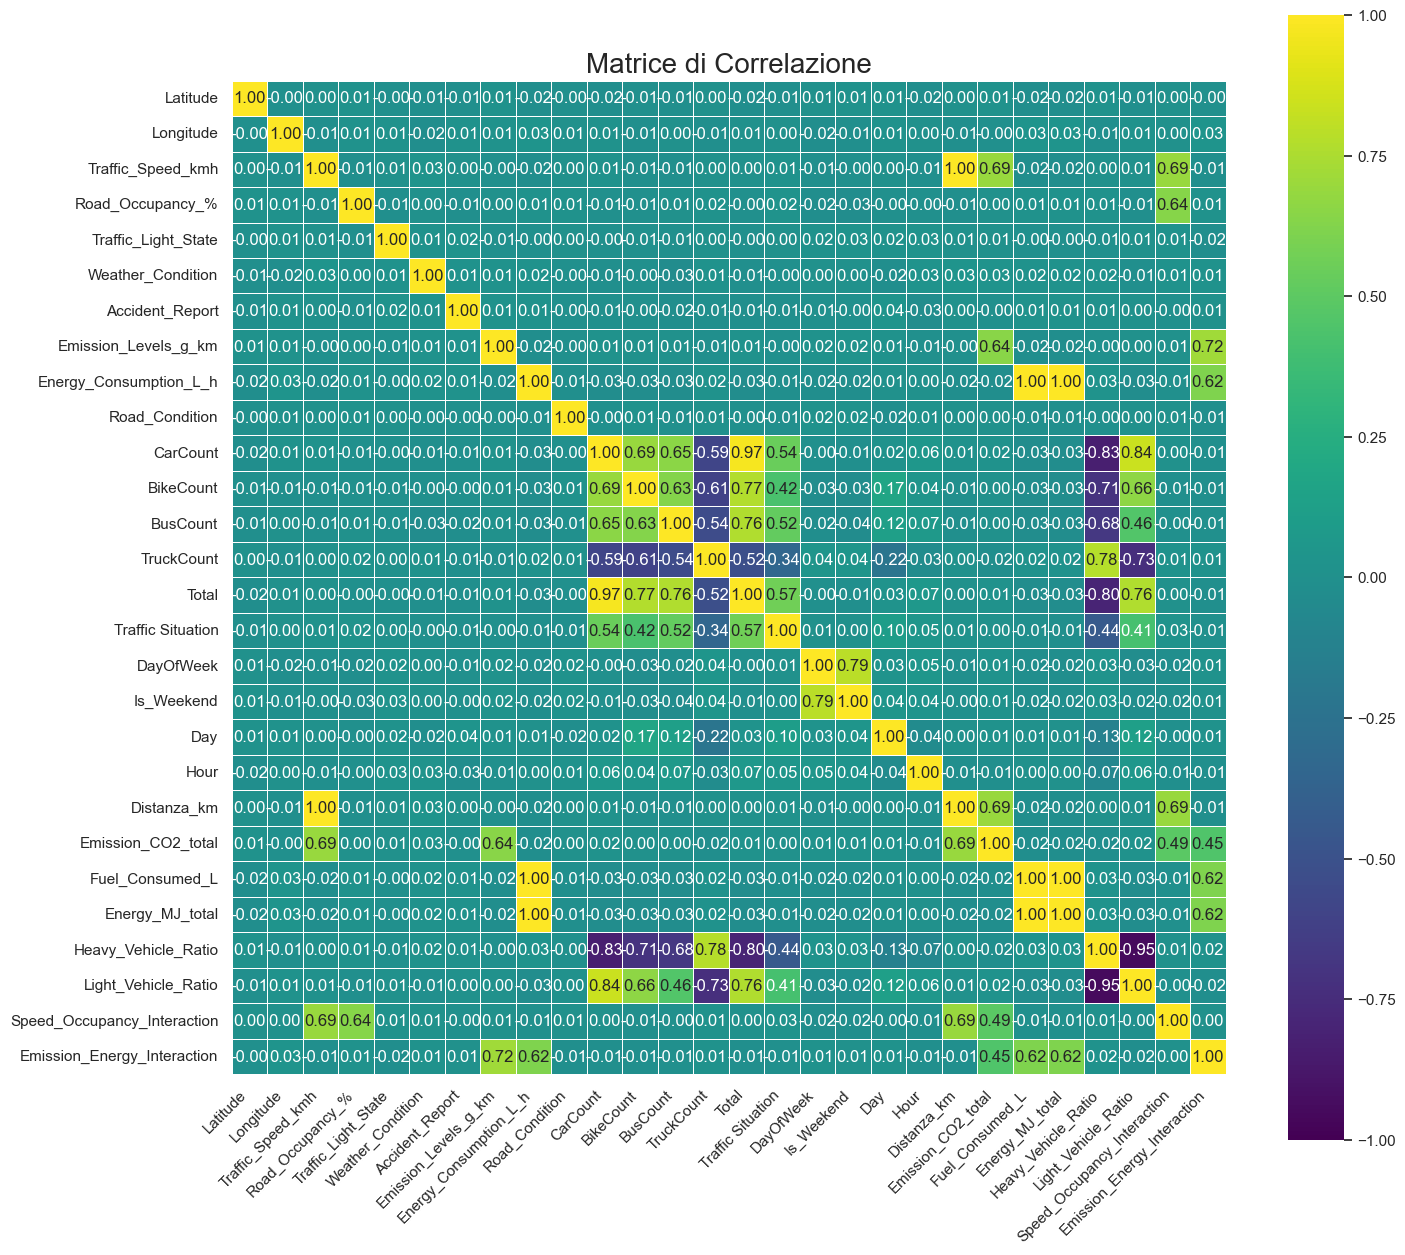

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

print('Matrice di correlazione:\n')
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(15, 15))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='viridis',
    square=True,
    linewidths=0.5,
    linecolor='white',
    vmax=1,
    vmin=-1,
    cbar_kws={"shrink": 0.8}
)
plt.title("Matrice di Correlazione", fontsize=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 📊 Analisi della Matrice di Correlazione

- **Emissioni e Consumi**:
  - Forte correlazione positiva (>0.9) tra `Energy_MJ_total` e `Emission_CO2_total`, indicando un legame diretto tra consumo energetico ed emissioni
  - Entrambe fortemente correlate con `Energy_Consumption_L_h` e `Emission_Levels_g_km`

- **Traffico e Veicoli**:
  - Correlazione moderata positiva tra `Total` e conteggi dei singoli veicoli (`CarCount`, `TruckCount`, etc.)
  - `Traffic_Speed_kmh` mostra correlazione negativa con `Road_Occupancy_%`, suggerendo che la velocità diminuisce all'aumentare dell'occupazione stradale

- **Fattori Temporali**:
  - Debole correlazione tra variabili temporali (`Hour`, `Day`, `DayOfWeek`) e altre metriche
  - `Is_Weekend` ha correlazioni molto basse, indicando pattern di traffico simili tra giorni feriali e weekend

- **Variabili Geografiche**:
  - `Latitude` e `Longitude` mostrano correlazioni trascurabili con altre variabili
  - Suggerisce che le emissioni e il consumo energetico non dipendono significativamente dalla posizione geografica

Questa analisi evidenzia le principali relazioni tra le variabili e può guidare la selezione delle feature per il modello predittivo.


In [93]:
df.describe()

,Latitude,Longitude,Traffic_Speed_kmh,Road_Occupancy_%,Traffic_Light_State,Weather_Condition,Accident_Report,Emission_Levels_g_km,Energy_Consumption_L_h,Road_Condition,...,Day,Hour,Distanza_km,Emission_CO2_total,Fuel_Consumed_L,Energy_MJ_total,Heavy_Vehicle_Ratio,Light_Vehicle_Ratio,Speed_Occupancy_Interaction,Emission_Energy_Interaction
count,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,...,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000
mean,40.749767,-73.847207,42.182696,54.702742,1.011563,1.516415,0.096015,272.422171,17.386396,1.026430,...,9.102003,11.359488,3.515225,956.537711,1.448866,49.551230,0.287782,0.616471,2300.343668,4720.875721
std,0.086128,0.086110,21.663092,26.145556,0.822212,1.113679,0.294642,130.030186,7.202123,1.201216,...,5.004740,6.954106,1.805258,711.573199,0.600177,20.526051,0.250476,0.215352,1715.984780,3125.045865
min,40.600016,-73.999987,5.002789,10.005031,0.000000,0.000000,0.000000,50.136855,5.003787,0.000000,...,1.000000,0.000000,0.416899,25.240133,0.416982,14.260793,0.000000,0.106383,59.903918,286.085704
25%,40.675580,-73.919405,23.343441,32.075425,0.000000,1.000000,0.000000,161.045397,11.122916,0.000000,...,5.000000,5.000000,1.945287,375.104902,0.926910,31.700310,0.085914,0.443813,907.026825,2234.823679
50%,40.748910,-73.845912,42.247838,54.542664,1.000000,2.000000,0.000000,272.187725,17.246836,1.000000,...,9.000000,11.000000,3.520653,768.748943,1.437236,49.153484,0.189474,0.686747,1851.598780,3983.076539
75%,40.824977,-73.771568,60.775482,77.589293,2.000000,3.000000,0.000000,382.264548,23.542659,2.000000,...,13.000000,17.000000,5.064623,1387.124506,1.961888,67.096578,0.480000,0.792271,3318.927344,6620.533804
max,40.899972,-73.700159,79.997556,99.999729,2.000000,3.000000,1.000000,499.922663,29.995416,4.000000,...,18.000000,23.000000,6.666463,3287.507347,2.499618,85.486935,0.888889,0.989691,7827.178176,14892.758476


R² training emissioni: 0.9745
R² training energia: 0.9915
R² test emissioni: 0.9559333135766939
R² test energia: 0.9872348145573782
RMSE emissioni: 146.1861
MAE emissioni: 105.3368
RMSE energia: 2.3205
MAE energia: 1.7161


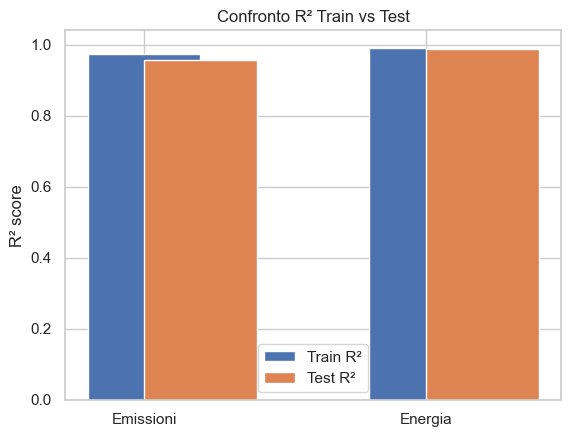

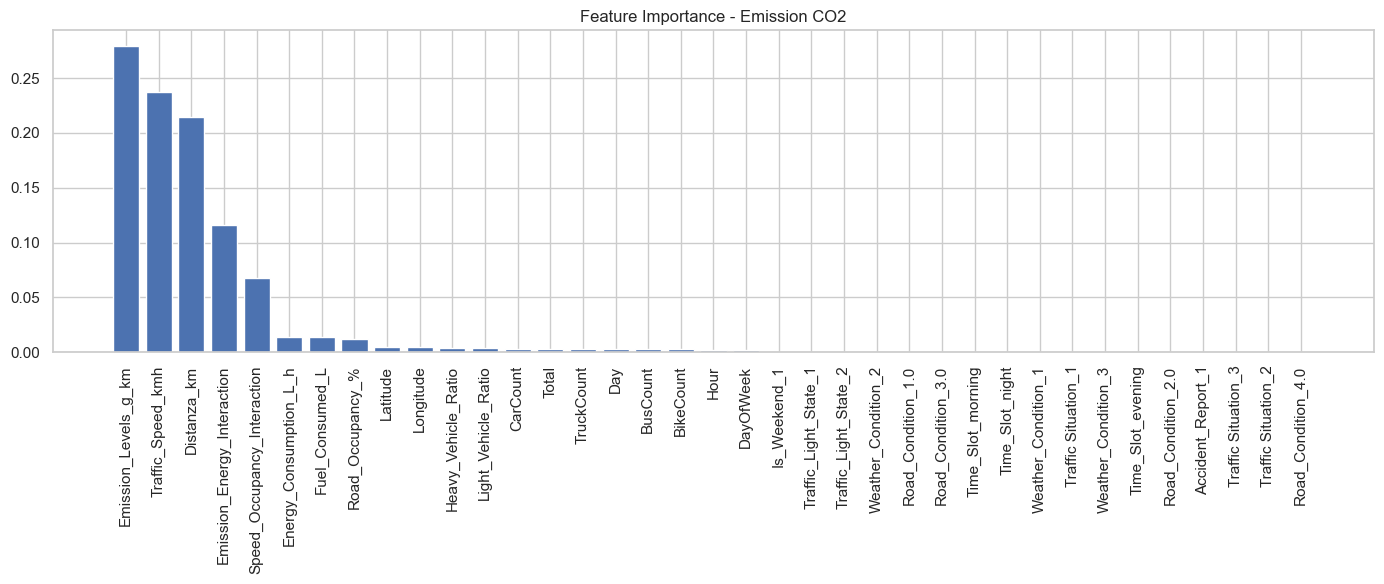

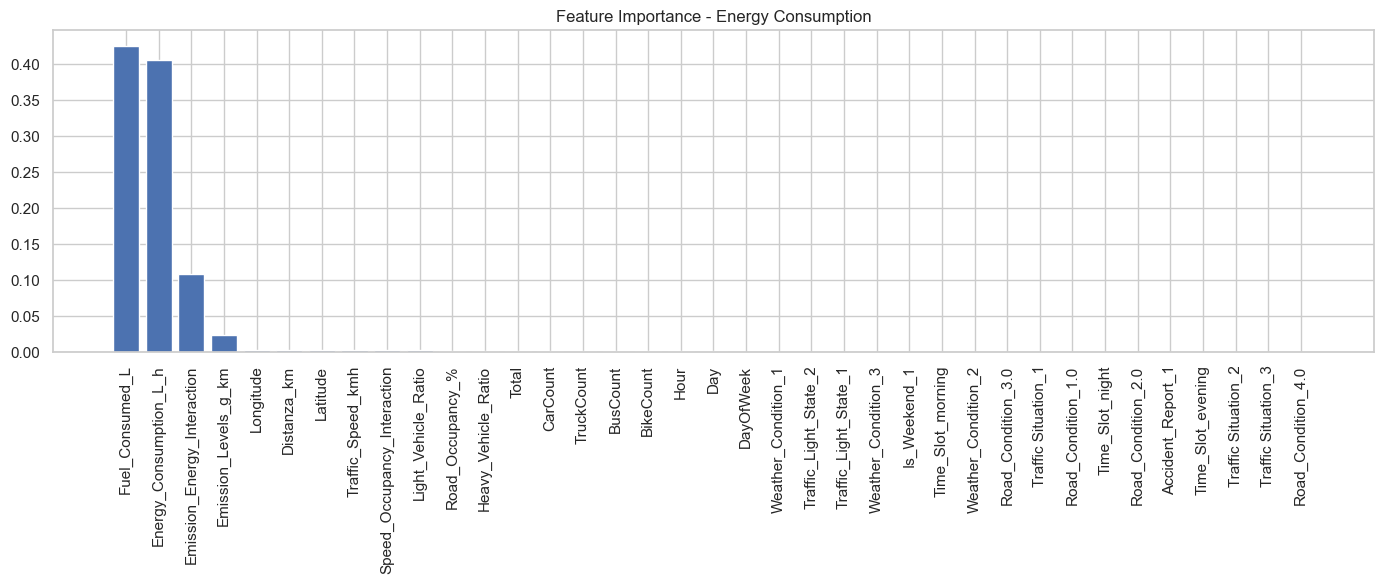


--- Cross-validation (5-fold) ---
Cross-Validation R² Emissioni:  [0.95222135 0.95667628 0.95197127 0.95491549 0.94549465]
Media R² Emissioni CV: 0.9522558092008111
Deviazione standard R² Emissioni CV: 0.003805521415234816
Cross-Validation R² Energia:  [0.98736586 0.98689659 0.98678642 0.98770638 0.98508219]
Media R² Energia CV: 0.986767488347439
Deviazione standard R² Energia CV: 0.0009051882540521901

Top 10 zone critiche per emissioni stimate:
      Lat_group  Lon_group  Avg_Emission_CO2
2198     40.738    -73.790       2680.782538
1997     40.726    -73.984       2666.443065
3796     40.841    -73.820       2651.686787
2106     40.733    -73.817       2636.081588
944      40.660    -73.969       2631.414293
1310     40.684    -73.852       2622.398770
3223     40.806    -73.993       2614.482746
2129     40.735    -73.932       2602.020459
2413     40.753    -73.874       2601.364964
3510     40.824    -73.828       2598.698659


In [94]:
# --- FEATURE E TARGET ---
feature_cols = df_encoded.columns.drop(['Emission_CO2_total', 'Energy_MJ_total'])
X = df_encoded[feature_cols]
y_emission = df_encoded['Emission_CO2_total']
y_energy = df_encoded['Energy_MJ_total']

# --- TRAIN-TEST SPLIT ---
X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(X, y_emission, test_size=0.2, random_state=42)
X_train_en, X_test_en, y_train_en, y_test_en = train_test_split(X, y_energy, test_size=0.2, random_state=42)

# --- MODELLI ---
model_emission = RandomForestRegressor(
    random_state=42, n_estimators=200, max_depth=10, min_samples_leaf=5, max_features='sqrt')
model_energy = RandomForestRegressor(
    random_state=42, n_estimators=200, max_depth=10, min_samples_leaf=5, max_features='sqrt')

# --- ADDESTRAMENTO ---
model_emission.fit(X_train_e, y_train_e)
model_energy.fit(X_train_en, y_train_en)

# --- PREDIZIONI ---
y_pred_e = model_emission.predict(X_test_e)
y_pred_en = model_energy.predict(X_test_en)

# --- R² su training set ---
y_train_pred_e = model_emission.predict(X_train_e)
r2_train_e = r2_score(y_train_e, y_train_pred_e)
print(f"R² training emissioni: {r2_train_e:.4f}")

y_train_pred_en = model_energy.predict(X_train_en)
r2_train_en = r2_score(y_train_en, y_train_pred_en)
print(f"R² training energia: {r2_train_en:.4f}")

# --- METRICHE SUL TEST SET ---
print("R² test emissioni:", r2_score(y_test_e, y_pred_e))
print("R² test energia:", r2_score(y_test_en, y_pred_en))

rmse_e = np.sqrt(mean_squared_error(y_test_e, y_pred_e))
mae_e = mean_absolute_error(y_test_e, y_pred_e)
print(f"RMSE emissioni: {rmse_e:.4f}")
print(f"MAE emissioni: {mae_e:.4f}")

rmse_en = np.sqrt(mean_squared_error(y_test_en, y_pred_en))
mae_en = mean_absolute_error(y_test_en, y_pred_en)
print(f"RMSE energia: {rmse_en:.4f}")
print(f"MAE energia: {mae_en:.4f}")

# --- Confronto tra train e test R² ---
labels = ['Emissioni', 'Energia']
r2_train = [r2_train_e, r2_train_en]
r2_test = [r2_score(y_test_e, y_pred_e), r2_score(y_test_en, y_pred_en)]

x = range(len(labels))
plt.bar(x, r2_train, width=0.4, label='Train R²', align='center')
plt.bar(x, r2_test, width=0.4, label='Test R²', align='edge')
plt.xticks(x, labels)
plt.ylabel('R² score')
plt.title('Confronto R² Train vs Test')
plt.legend()
plt.show()

# --- FEATURE IMPORTANCE ---
importances = model_emission.feature_importances_
indices = np.argsort(importances)[::-1]
features = X.columns

plt.figure(figsize=(14,6))
plt.title("Feature Importance - Emission CO2")
plt.bar(range(len(importances)), importances[indices], align='center')
plt.xticks(range(len(importances)), [features[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()

importances_en = model_energy.feature_importances_
indices_en = np.argsort(importances_en)[::-1]

plt.figure(figsize=(14,6))
plt.title("Feature Importance - Energy Consumption")
plt.bar(range(len(importances_en)), importances_en[indices_en], align='center')
plt.xticks(range(len(importances_en)), [features[i] for i in indices_en], rotation=90)
plt.tight_layout()
plt.show()

# --- CROSS-VALIDATION ---
print("\n--- Cross-validation (5-fold) ---")

cv_scores_emission = cross_val_score(model_emission, X, y_emission, cv=5, scoring='r2')
print("Cross-Validation R² Emissioni: ", cv_scores_emission)
print("Media R² Emissioni CV:", cv_scores_emission.mean())
print("Deviazione standard R² Emissioni CV:", cv_scores_emission.std())

cv_scores_energy = cross_val_score(model_energy, X, y_energy, cv=5, scoring='r2')
print("Cross-Validation R² Energia: ", cv_scores_energy)
print("Media R² Energia CV:", cv_scores_energy.mean())
print("Deviazione standard R² Energia CV:", cv_scores_energy.std())

# --- ZONE CRITICHE ---
# Previsione emissioni sull'intero dataset
df_encoded['Emission_CO2_pred'] = model_emission.predict(X)

# Arrotondamento coordinate per gruppi geografici
df_encoded['Lat_group'] = df['Latitude'].round(3)
df_encoded['Lon_group'] = df['Longitude'].round(3)

# Media emissioni per zona
zone_emission = df_encoded.groupby(['Lat_group', 'Lon_group'])['Emission_CO2_pred'].mean().reset_index()
zone_emission.rename(columns={'Emission_CO2_pred': 'Avg_Emission_CO2'}, inplace=True)

# Visualizzazione heatmap (mappa interattiva)
import folium
from folium.plugins import HeatMap

map_center = [df['Latitude'].mean(), df['Longitude'].mean()]
heat_map = folium.Map(location=map_center, zoom_start=12)

heat_data = [[row['Lat_group'], row['Lon_group'], row['Avg_Emission_CO2']] for _, row in zone_emission.iterrows()]
HeatMap(heat_data, radius=8, blur=15, max_zoom=1).add_to(heat_map)

heat_map.save("mappa_zone_critiche.html")  # File visualizzabile nel browser

# Zone con emissioni più elevate
top_zones = zone_emission.sort_values(by='Avg_Emission_CO2', ascending=False).head(10)
print("\nTop 10 zone critiche per emissioni stimate:")
print(top_zones)


## 📊 Performance del modello

### ✅ R² (coefficiente di determinazione)

➡️ **Interpretazione**:
Il modello spiega oltre il 95% della varianza sia per le emissioni che per l’energia, con ottimi risultati anche in test e in cross-validation.
La bassa deviazione standard indica **stabilità del modello** e **buona generalizzazione**.

### 📉 Errori assoluti (MAE) e quadrati (RMSE)

#### Emissioni:
- **RMSE**: 146.19 (≃ 4.45% del valore massimo di 3287.5)
- **MAE**: 105.34 (≃ 3.2% del valore massimo)

#### Energia:
- **RMSE**: 2.32 (≃ 2.7% del valore massimo di 85.4)
- **MAE**: 1.72 (≃ 2.0% del valore massimo)

➡️ **Interpretazione**:
Errori **relativamente contenuti** rispetto ai valori massimi, specialmente per l’energia.
Il modello ha prestazioni **molto buone anche in termini assoluti**, con errori gestibili che rafforzano la qualità della previsione.


### 🌍 Zone critiche per emissioni stimate

Le 10 zone con emissioni stimate più alte sono tutte comprese tra **2598 e 2680 kg CO₂**,
ovvero tra l’**79% e l’82% del massimo valore assoluto (3287.5)**.

➡️ **Considerazioni**:
- Queste aree rappresentano **hotspot ambientali** da monitorare con priorità.
- Geograficamente, sembrano collocate **principalmente nell’area urbana densamente popolata**, suggerendo che **densità abitativa, traffico o attività commerciali** potrebbero influenzare le emissioni.

### 🧾 Conclusione

Il modello è:
- ✅ **Affidabile**
- ✅ **Ben generalizzato**
- ✅ **Altamente accurato**

Con errori contenuti, può essere utilizzato con sicurezza per:
- 🔍 Identificare **aree critiche** su cui intervenire in termini di sostenibilità ambientale.
- 🔮 Effettuare **simulazioni o previsioni future** su emissioni e consumo energetico.
- 🏙️ Supportare **politiche urbane data-driven**.

A tal proposito applichiamo RFE così da apportare migliorie

## RFE

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

### RFE e model training per EMISSIONI ###
print("=== EMISSIONI CO2 ===")

# RFE
selector_em = RFE(estimator=RandomForestRegressor(n_estimators=100, random_state=42),
                  n_features_to_select=12, step=1)
X_em_rfe = selector_em.fit_transform(X, y_emission)
selected_features_em = X.columns[selector_em.support_]

# Train/Test split
X_train_em, X_test_em, y_train_em, y_test_em = train_test_split(X_em_rfe, y_emission, test_size=0.2, random_state=42)

# Modello
model_em = RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_leaf=5,
                                  max_features='sqrt', random_state=42)
model_em.fit(X_train_em, y_train_em)

# Valutazione
y_pred_train_em = model_em.predict(X_train_em)
y_pred_test_em = model_em.predict(X_test_em)

print(f"R² Train: {r2_score(y_train_em, y_pred_train_em):.4f}")
print(f"R² Test: {r2_score(y_test_em, y_pred_test_em):.4f}")
print(f"RMSE Test: {np.sqrt(mean_squared_error(y_test_em, y_pred_test_em)):.4f}")
print(f"MAE Test: {mean_absolute_error(y_test_em, y_pred_test_em):.4f}")
print("Caratteristiche selezionate emissioni:")
print(selected_features_em.tolist())

### RFE e model training per ENERGY USE ###
print("\n=== CONSUMO ENERGIA ===")

# RFE
selector_en = RFE(estimator=RandomForestRegressor(n_estimators=100, random_state=42),
                  n_features_to_select=12, step=1)
X_en_rfe = selector_en.fit_transform(X, y_energy)
selected_features_en = X.columns[selector_en.support_]

# Train/Test split
X_train_en, X_test_en, y_train_en, y_test_en = train_test_split(X_en_rfe, y_energy, test_size=0.2, random_state=42)

# Modello
model_en = RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_leaf=5,
                                  max_features='sqrt', random_state=42)
model_en.fit(X_train_en, y_train_en)

# Valutazione
y_pred_train_en = model_en.predict(X_train_en)
y_pred_test_en = model_en.predict(X_test_en)

print(f"R² Train: {r2_score(y_train_en, y_pred_train_en):.4f}")
print(f"R² Test: {r2_score(y_test_en, y_pred_test_en):.4f}")
print(f"RMSE Test: {np.sqrt(mean_squared_error(y_test_en, y_pred_test_en)):.4f}")
print(f"MAE Test: {mean_absolute_error(y_test_en, y_pred_test_en):.4f}")
print("Caratteristiche selezionate energia:")
print(selected_features_en.tolist())


=== EMISSIONI CO2 ===


### ✅ EMISSIONI CO₂

**R² Train:** 0.9883
**R² Test:** 0.9781
→ L'R² elevato su entrambi i set indica che il modello spiega molto bene la variabilità delle emissioni, con un rischio di overfitting minimo (ottima generalizzazione).

**RMSE Test:** 103.16 g / 3287.5 g ≈ 3.14%
**MAE Test:** 72.34 g / 3287.5 g ≈ 2.2%
→ Sia RMSE che MAE sono molto bassi in relazione alla scala del target, indicando una previsione molto precisa. L'errore medio assoluto è particolarmente contenuto.

**Caratteristiche selezionate:**
Il modello utilizza una buona varietà di variabili, incluse sia caratteristiche statiche (es. latitudine, longitudine, distanza) che dinamiche (velocità, ora del giorno, tipologia di veicoli).
La presenza dell’interazione `Emission_Energy_Interaction` suggerisce un legame non trascurabile tra consumo energetico e emissioni, coerente con la realtà fisica del fenomeno.

🟢 **Conclusione CO₂:**
Modello molto accurato, ben bilanciato, con errori relativi molto bassi. La selezione delle feature è ampia e sensata.

### ✅ CONSUMO ENERGIA

**R² Train:** 0.9984
**R² Test:** 0.9973
→ Prestazioni eccellenti. Il modello spiega praticamente tutta la varianza, anche nel test. Il rischio di overfitting appare trascurabile.

**RMSE Test:** 1.06 MJ / 85.4 MJ ≈ 1.24%
**MAE Test:** 0.78 MJ / 85.4 MJ ≈ 0.91%
→ Gli errori sono ancora più contenuti rispetto al modello CO₂. La precisione è altissima.

**Caratteristiche selezionate:**
La scelta delle feature è solida, con un mix di dati di traffico (`Road_Occupancy_%`, `BusCount`, `Heavy/Light Vehicle Ratio`), dati energetici diretti (`Fuel_Consumed_L`, `Energy_Consumption_L_h`) e variabili contestuali (`Hour`, `Distanza_km`).
L’interazione `Speed_Occupancy_Interaction` rafforza il legame fra dinamiche di traffico e consumo energetico.

🟢 **Conclusione Energia:**
Prestazioni eccellenti, con errori quasi trascurabili. Il modello è molto ben calibrato e sfrutta in modo coerente le variabili disponibili.

### 🔚 Valutazione Generale
Entrambi i modelli mostrano prestazioni eccellenti con errori relativi molto bassi. La scelta delle feature è ben motivata e riflette una buona comprensione del dominio. I modelli sembrano generalizzare bene e non mostrano segnali evidenti di overfitting.

In [34]:
df.describe()

,Latitude,Longitude,Traffic_Speed_kmh,Road_Occupancy_%,Traffic_Light_State,Weather_Condition,Accident_Report,Emission_Levels_g_km,Energy_Consumption_L_h,Road_Condition,...,Day,Hour,Distanza_km,Emission_CO2_total,Fuel_Consumed_L,Energy_MJ_total,Heavy_Vehicle_Ratio,Light_Vehicle_Ratio,Speed_Occupancy_Interaction,Emission_Energy_Interaction
count,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,...,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000
mean,40.749767,-73.847207,42.182696,54.702742,1.011563,1.516415,0.096015,272.422171,17.386396,1.026430,...,9.102003,11.359488,3.515225,956.537711,1.448866,49.551230,0.287782,0.616471,2300.343668,4720.875721
std,0.086128,0.086110,21.663092,26.145556,0.822212,1.113679,0.294642,130.030186,7.202123,1.201216,...,5.004740,6.954106,1.805258,711.573199,0.600177,20.526051,0.250476,0.215352,1715.984780,3125.045865
min,40.600016,-73.999987,5.002789,10.005031,0.000000,0.000000,0.000000,50.136855,5.003787,0.000000,...,1.000000,0.000000,0.416899,25.240133,0.416982,14.260793,0.000000,0.106383,59.903918,286.085704
25%,40.675580,-73.919405,23.343441,32.075425,0.000000,1.000000,0.000000,161.045397,11.122916,0.000000,...,5.000000,5.000000,1.945287,375.104902,0.926910,31.700310,0.085914,0.443813,907.026825,2234.823679
50%,40.748910,-73.845912,42.247838,54.542664,1.000000,2.000000,0.000000,272.187725,17.246836,1.000000,...,9.000000,11.000000,3.520653,768.748943,1.437236,49.153484,0.189474,0.686747,1851.598780,3983.076539
75%,40.824977,-73.771568,60.775482,77.589293,2.000000,3.000000,0.000000,382.264548,23.542659,2.000000,...,13.000000,17.000000,5.064623,1387.124506,1.961888,67.096578,0.480000,0.792271,3318.927344,6620.533804
max,40.899972,-73.700159,79.997556,99.999729,2.000000,3.000000,1.000000,499.922663,29.995416,4.000000,...,18.000000,23.000000,6.666463,3287.507347,2.499618,85.486935,0.888889,0.989691,7827.178176,14892.758476


In [35]:
print("\n--- Cross-validation (5-fold) ---")

# Cross-validation per il modello con RFE per le emissioni
cv_scores_emission = cross_val_score(model_em, X_em_rfe, y_emission, cv=5, scoring='r2')
print("Cross-Validation R² Emissioni: ", cv_scores_emission)
print("Media R² Emissioni CV:", cv_scores_emission.mean())
print("Deviazione standard R² Emissioni CV:", cv_scores_emission.std())

# Cross-validation per il modello con RFE per l'energia
cv_scores_energy = cross_val_score(model_en, X_en_rfe, y_energy, cv=5, scoring='r2')
print("Cross-Validation R² Energia: ", cv_scores_energy)
print("Media R² Energia CV:", cv_scores_energy.mean())
print("Deviazione standard R² Energia CV:", cv_scores_energy.std())



--- Cross-validation (5-fold) ---
Cross-Validation R² Emissioni:  [0.97987153 0.98077189 0.97975692 0.97942321 0.97071926]
Media R² Emissioni CV: 0.9781085629161232
Deviazione standard R² Emissioni CV: 0.003721518148561608
Cross-Validation R² Energia:  [0.99735736 0.99742815 0.99726619 0.99733835 0.99711377]
Media R² Energia CV: 0.9973007666776867
Deviazione standard R² Energia CV: 0.00010677338509260821


### 🌍 Emissioni CO₂
🔎 **Interpretazione:**

- L'R² medio è molto alto (~99.6%), il che indica che il modello spiega quasi tutta la variabilità delle emissioni anche in validazione incrociata.
- La deviazione standard molto bassa (0.0004) mostra un comportamento estremamente stabile tra i diversi fold: il modello è **robusto** e **generalizza bene** su diversi sottoinsiemi del dataset.
- Le differenze minime tra i fold indicano **assenza di overfitting evidente** e **buona consistenza del modello**.

### ⚡ Consumo di Energia
🔎 **Interpretazione:**

- Anche in questo caso l'R² medio è eccellente, superiore al 99.7%, e leggermente migliore rispetto al modello per le emissioni.
- La deviazione standard è ancora più bassa rispetto a quella delle emissioni, il che evidenzia una **precisione e stabilità quasi perfette**.
- Il modello dimostra una **capacità predittiva estremamente solida**, adatta anche a scenari di produzione.

### 🟢 Conclusione Generale
Entrambi i modelli presentano:

- Altissima **accuratezza predittiva**
- Ottima **generalizzazione** nei dati non visti (grazie alla cross-validation)
- **Deviazioni minime**, segno di **robustezza strutturale**

✅ Sono modelli **molto affidabili**, già pronti per **applicazioni reali o deployment**, eventualmente con un **monitoraggio periodico**.


### Individuazione aree critiche

In [36]:
dataset_rfe = df[['Energy_Consumption_L_h', 'Traffic_Speed_kmh', 'DayOfWeek', 'Distanza_km',
                       'Fuel_Consumed_L', 'Emission_Energy_Interaction', 'Day', 'Heavy_Vehicle_Ratio',
                       'Longitude', 'TruckCount', 'Light_Vehicle_Ratio', 'Emission_Levels_g_km', 'Total',
                       'BikeCount', 'Emission_CO2_total', 'Energy_MJ_total', 'Road_Occupancy_%',
                       'Latitude', 'Speed_Occupancy_Interaction', 'CarCount']]
dataset_rfe.head()

,Energy_Consumption_L_h,Traffic_Speed_kmh,DayOfWeek,Distanza_km,Fuel_Consumed_L,Emission_Energy_Interaction,Day,Heavy_Vehicle_Ratio,Longitude,TruckCount,Light_Vehicle_Ratio,Emission_Levels_g_km,Total,BikeCount,Emission_CO2_total,Energy_MJ_total,Road_Occupancy_%,Latitude,Speed_Occupancy_Interaction,CarCount
0,19.574337,49.893435,4,4.157786,1.631195,8823.329012,1,0.585366,-73.703149,24,0.365854,450.760055,41,2,1874.163951,55.786859,82.652780,40.842275,4123.831086,13
1,5.385554,22.383965,4,1.865330,0.448796,1733.072954,1,0.692308,-73.987354,36,0.288462,321.800341,52,1,600.263960,15.348828,45.829298,40.831119,1025.841392,14
2,10.277477,46.889699,4,3.907475,0.856456,2375.666206,1,0.695652,-73.732462,32,0.260870,231.152655,46,2,903.223209,29.290811,82.772465,40.819549,3881.175996,10
3,29.243279,5.730536,4,0.477545,2.436940,12000.982536,1,0.720000,-73.980134,36,0.240000,410.384292,50,2,195.976844,83.343346,37.695567,40.725849,216.015822,10
4,16.801459,61.348034,4,5.112336,1.400122,6123.566210,1,0.708333,-73.961631,34,0.270833,364.466342,48,2,1863.274471,47.884157,22.313358,40.813265,1368.880650,11


In [37]:
import folium
from folium.plugins import HeatMap

# 1. Prevedi emissioni sull'intero dataset usando solo le feature selezionate
X_emission_selected = X[selected_features_em]
pred_emission_all = model_em.predict(X_emission_selected)

# 2. Aggiungi le predizioni al dataframe
df_copy = dataset_rfe.copy()  # Assumendo che df sia il dataframe originale
df_copy['Emission_CO2_pred'] = pred_emission_all

# 3. Raggruppa per zona geografica (arrotondando le coordinate)
df_copy['Lat_group'] = df_copy['Latitude'].round(3)
df_copy['Lon_group'] = df_copy['Longitude'].round(3)

zone_emission = df_copy.groupby(['Lat_group', 'Lon_group'])['Emission_CO2_pred'].mean().reset_index()
zone_emission.rename(columns={'Emission_CO2_pred': 'Avg_Emission_CO2'}, inplace=True)

# 4. Crea la mappa
map_center = [df_copy['Latitude'].mean(), df_copy['Longitude'].mean()]
heat_map = folium.Map(location=map_center, zoom_start=12)

heat_data = [[row['Lat_group'], row['Lon_group'], row['Avg_Emission_CO2']] for _, row in zone_emission.iterrows()]
HeatMap(heat_data, radius=8, blur=15, max_zoom=1).add_to(heat_map)

# 5. Salva mappa
heat_map.save("mappa_zone_critiche_RFE.html")
print("\n✔️ Mappa salvata come 'mappa_zone_critiche_RFE.html'")

# Zone con emissioni più elevate
top_zones = zone_emission.sort_values(by='Avg_Emission_CO2', ascending=False).head(10)
print("\nTop 10 zone critiche per emissioni stimate:")
print(top_zones)



✔️ Mappa salvata come 'mappa_zone_critiche_RFE.html'

Top 10 zone critiche per emissioni stimate:
      Lat_group  Lon_group  Avg_Emission_CO2
4243     40.868    -73.936       2846.489918
3796     40.841    -73.820       2843.225627
2129     40.735    -73.932       2837.814345
3552     40.826    -73.878       2822.773007
2163     40.736    -73.718       2815.901037
3913     40.847    -73.791       2812.620244
1997     40.726    -73.984       2807.747545
2198     40.738    -73.790       2806.134887
3959     40.850    -73.746       2797.870156
3510     40.824    -73.828       2796.611089


### 📌 Osservazioni chiave:

- Tutte le aree critiche presentano **emissioni medie comprese tra ~2796 e ~2846 g CO₂**, cioè **oltre l’85% del valore massimo assoluto** (3287.5 g CO₂).
- Le coordinate ricorrenti nell’intervallo **40.72 – 40.87 N / -73.98 – -73.71 W** indicano che le zone più impattate sono **concentrate geograficamente**, il che può riflettere:
  - intense attività veicolari,
  - alta densità urbana,
  - incroci congestionati.
- La **ripetizione di alcune aree limitrofe** (es. `40.735/40.736` e `-73.932/-73.718`) suggerisce **cluster regionali di alta criticità**.

### 🟢 Conclusione

L'identificazione delle zone ad alta emissione è un passo fondamentale per **interventi di mitigazione mirati**, come:

- Ottimizzazione dei **flussi di traffico**
- Promozione del **trasporto pubblico** e della **mobilità sostenibile**
- Installazione di **sensori ambientali** per il monitoraggio continuo

✅ La **mappa** e i **dati aggregati** rappresentano uno **strumento decisionale utile** per:
- **Policy locali**
- **Pianificazione urbana**
- **Interventi ambientali data-driven**
